In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
for w in words[:3]:
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

e m
m m
m a
o l
l i
i v
v i
i a
a v
v a


In [4]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [5]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [6]:
import torch

N = torch.zeros((28, 28), dtype=torch.int32)

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)}

stoi['<S>'] = 26
stoi['<E>'] = 27



In [8]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)}

stoi['<S>'] = 26
stoi['<E>'] = 27

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [9]:
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

In [11]:
itos = {i:s for s,i in stoi.items()}

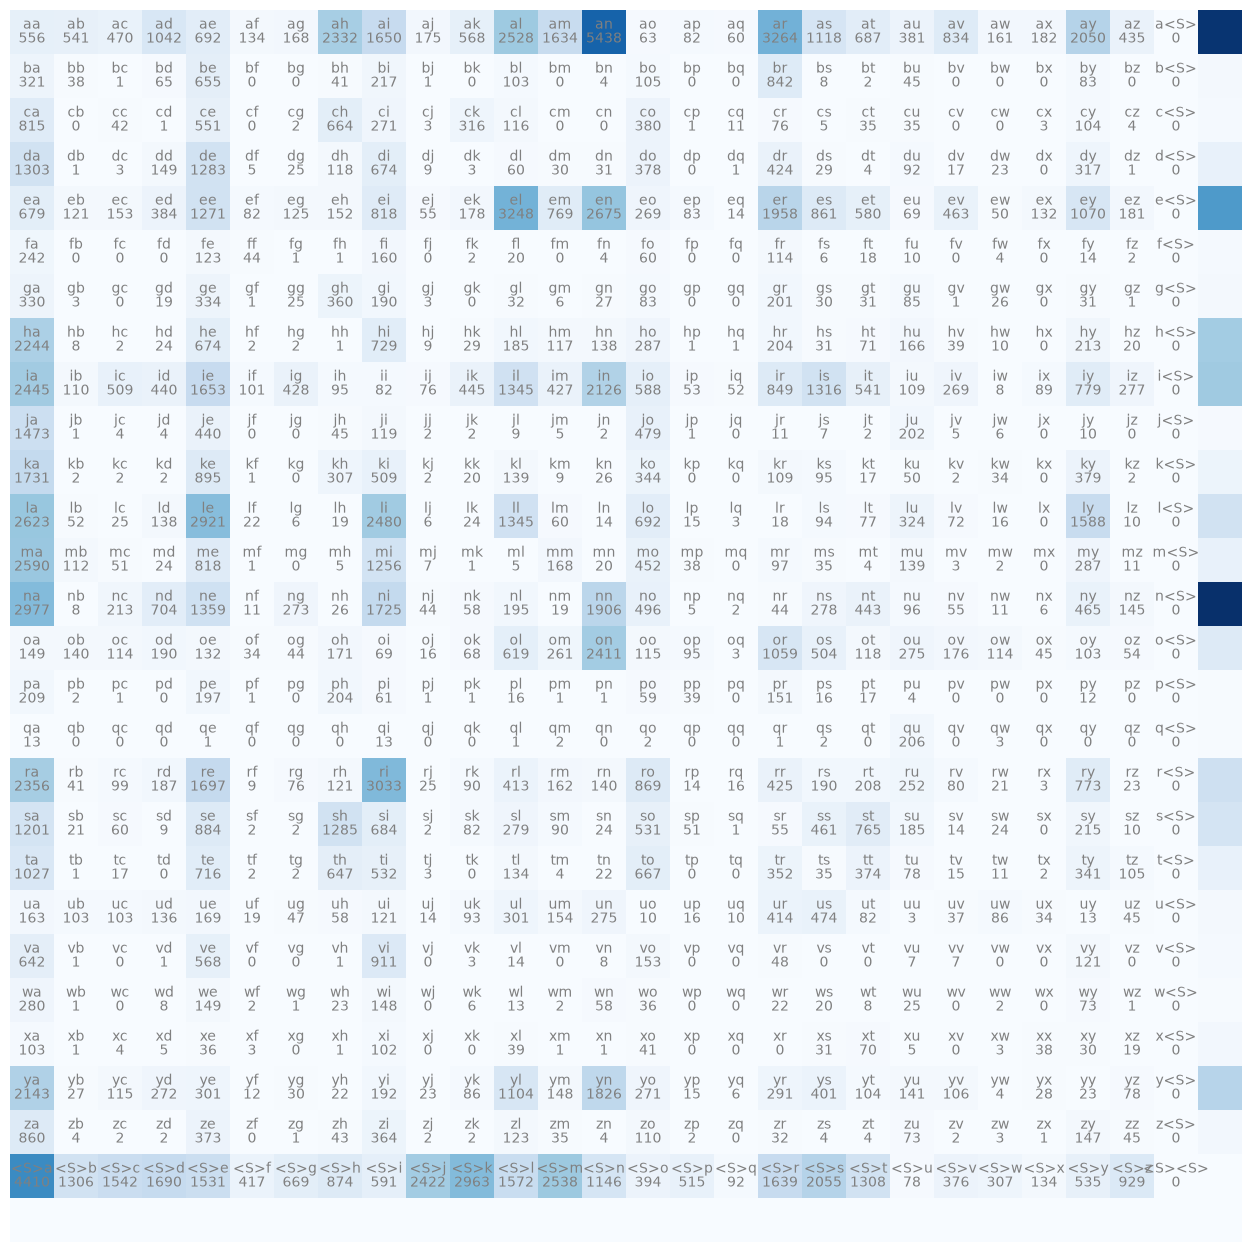

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')

plt.axis('off');

In [14]:
N[0]

tensor([ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
        1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
        2050,  435,    0, 6640], dtype=torch.int32)

In [15]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0164, 0.0160, 0.0139, 0.0308, 0.0204, 0.0040, 0.0050, 0.0688, 0.0487,
        0.0052, 0.0168, 0.0746, 0.0482, 0.1605, 0.0019, 0.0024, 0.0018, 0.0963,
        0.0330, 0.0203, 0.0112, 0.0246, 0.0048, 0.0054, 0.0605, 0.0128, 0.0000,
        0.1960])

In [17]:
g = torch.Generator().manual_seed(2147483647)

p = N[0].float()
p = p / p.sum()

ix = torch.multinomial(
    p,
    num_samples=1,
    replacement=True,
    generator=g
).item()

itos[ix]

'h'

In [18]:
g = torch.Generator().manual_seed(2147483647)

p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [19]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [20]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):

    out = []
    ix = 0

    while True:

        p = N[ix].float()
        #p = N[ix].float()
        #p = p / p.sum()
        #p = torch.ones(27) / 27.0

        p = torch.ones(27) / 27.0

        ix = torch.multinomial(
            p,
            num_samples=1,
            replacement=True,
            generator=g
        ).item()

        out.append(itos[ix])

        if ix == 0:
            break

    print(''.join(out))

dfy<S>na
<S>phmlvsljdr<S>luzixnwn<S>jnkuubjosmlgvl<S>llueba
tgdywqvckucisnhpu<S>ya
jd<S>jyrduwvklxqufephllkfnlnntjehvfolcwhzozxguctqnixdjwhcwubimwtva
eteyycmoxhmiqzjxa
jhxokxsqgexjqlx<S>lna
eftva
gjsnua
hcjltkcrvbctwpuia
lvztyrfwidnscyndxzisskfowynwqglnxnhigwk<S>ypcpnztpya
hcqukbqyxffhqgxiddgz<S>gwltjjrnwxcinjxrneh<S>rtbnkihbndyxnnla
jtxdygncbmdtmiza
gqzdwbtw<S>a
cr<S>b<S>fvotdidla
xolpkvpyzwuwgjxlteevholvma
gvxgdhk<S>a
bcma
ka
ovvvutupghr<S>vccpa
sevcqloinea
wigbdewbbbtk<S>kleia
hia
gseimibigmslmnmdvhspa
qoyibzya
woa
hjyhptgroa
nfnqgodmgyujscriwkgexi<S>znbzfs<S>rwn<S>kwukvjgcpppdoldyklwtnkbgdjflypsbxa
a
wfjhucdbbnofga
digfvlxpxhtbekklltxsdqbxipytlgjlxctdzooenjvyyxpuvs<S>irotkeoet<S>jpdocyjfh<S><S>vmiorerxptja
lexogkwnuuiuq<S>cnewwswuqubrmieolka
<S>yldcd<S>tsdbhjuxjdwldrjpuhowqmmdjrta
vpikyowyrjlfcbelebxegxxiba
grdonsqpmkmqkmezkfiqqskqqtnl<S>eisnhzpbentpea
eow<S>dpcu<S>gjljefdykicnnkyrqiwufekcxly<S>ijtoeopbvjzdsegfujglw<S>m<S>ga
vea
dloethzmercldzmsp<S>hxlkhgusbiesogbqtqebzoba
uibwqhfm